In [27]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [28]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [29]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [30]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        # Return True if state is equal to the goal state.
        if state == self.goal:
            return True
        else:
            return False
            # raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        legal_actions = []

        for action in MOVES:
            dr, dc = MOVES[action]
            row, col = state
            neighbour = (dr + row, dc + col)
            if (self.in_bounds(neighbour)) and (self.is_free(neighbour)):
                legal_actions.append(action)
        return legal_actions

        # raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

        # raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1

        # raise NotImplementedError("Complete GridProblem.action_cost")


In [ ]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)
        # raise NotImplementedError("Complete SearchAlgorithm.expand")

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [33]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path (from Part A)."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

In [ ]:
class WeightedGridProblem(GridProblem):
    """A grid problem where entering a cell costs that cell's terrain cost."""

    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
        terrain_costs: List[List[float]],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        terrain_costs:
            2D list, same shape as grid. terrain_costs[r][c] is the cost of
            ENTERING cell (r, c). All values must be >= 1.
        """
        super().__init__(grid, start, goal)
        self.terrain_costs = terrain_costs

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 1:
        # Return the cost of moving from state to next_state.
        #
        # Steps:
        # 1. Unpack next_state into row and col.
        # 2. Return self.terrain_costs[row][col].
        return self.terrain_costs[next_state[0]][next_state[1]]

    # raise NotImplementedError("Complete WeightedGridProblem.action_cost")

In [35]:
wtest_grid = [
    [0, 0, 0],
    [0, 0, 0],
    [0, 0, 0],
]

wtest_costs = [
    [1, 7, 1],
    [1, 1, 1],
    [1, 1, 1],
]

wtest_problem = WeightedGridProblem(
    wtest_grid, start=(0, 0), goal=(2, 2), terrain_costs=wtest_costs
)

# Entering the windy cell (0, 1) costs 7.
assert wtest_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 7
# Entering the calm cell (1, 0) costs 1.
assert wtest_problem.action_cost((0, 0), "DOWN", (1, 0)) == 1
# Everything inherited from GridProblem still works.
assert wtest_problem.actions((0, 0)) == ["DOWN", "RIGHT"]
assert wtest_problem.is_goal((2, 2)) is True

print("WeightedGridProblem self-check passed.")

WeightedGridProblem self-check passed.


In [ ]:
def manhattan_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 2:
    # Return the Manhattan distance between state and goal.
    #
    # Steps:
    # 1. Unpack state into (r1, c1) and goal into (r2, c2).
    r1, c1 = state
    r2, c2 = goal
    # 2. Return abs(r1 - r2) + abs(c1 - c2).
    return abs(r1 - r2) + abs(c1 - c2)


def euclidean_distance(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    # TODO 3:
    # Return the straight-line distance between state and goal.
    r1, c1 = state
    r2, c2 = goal
    # Hint: math.sqrt(...) or math.dist(state, goal).
    return math.sqrt((r1 - r2) ** 2 + (c1 - c2) ** 2)


def zero_heuristic(state: Tuple[int, int], goal: Tuple[int, int]) -> float:
    """h(n) = 0 for every node. Provided.

    A* with the zero heuristic degenerates into Uniform-Cost Search —
    admissible, consistent, and completely uninformative.
    """
    return 0.0

In [37]:
assert manhattan_distance((0, 0), (2, 2)) == 4
assert manhattan_distance((3, 5), (3, 5)) == 0
assert abs(euclidean_distance((0, 0), (3, 4)) - 5.0) < 1e-9
assert euclidean_distance((1, 1), (1, 1)) == 0
assert zero_heuristic((0, 0), (9, 9)) == 0

# Euclidean never exceeds Manhattan (so Manhattan dominates Euclidean).
for s in [(0, 0), (2, 7), (5, 1)]:
    assert euclidean_distance(s, (9, 9)) <= manhattan_distance(s, (9, 9)) + 1e-9

print("Heuristic self-check passed.")

Heuristic self-check passed.


In [ ]:
# Problem 5
class PriorityQueue:
    """A min-priority queue of (priority, node) pairs built on heapq."""

    def __init__(self):
        self._heap: List[Tuple[float, int, Node]] = []
        self._counter = itertools.count()

    def push(self, priority: float, node: Node) -> None:
        heapq.heappush(self._heap, (priority, next(self._counter), node))

    def pop(self) -> Node:
        """Remove and return the node with the LOWEST priority."""
        priority, count, node = heapq.heappop(self._heap)
        return node

    def __len__(self) -> int:
        return len(self._heap)

    def __bool__(self) -> bool:
        return len(self._heap) > 0

In [ ]:
# Problem 6
class BestFirstSearch(SearchAlgorithm):
    """Generic best-first search. Subclasses define the evaluation function f(n)."""

    algorithm_name = "BestFirst"

    def __init__(
        self,
        heuristic: Callable[[Tuple[int, int], Tuple[int, int]], float] = zero_heuristic,
    ):
        self.heuristic = heuristic

    def h(self, node: Node, problem: Problem) -> float:
        """Heuristic estimate from this node's state to the goal."""
        return self.heuristic(node.state, problem.goal)

    def evaluation(self, node: Node, problem: Problem) -> float:
        """f(n). Subclasses override this single method."""
        raise NotImplementedError("Subclasses must define evaluation(node, problem)")

    def search(self, problem: Problem) -> SearchResult:
        # TODO 4:
        # Implement the BEST-FIRST-SEARCH pseudocode above.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        initial_node = Node(state=problem.initial_state())
        # 2. Create a PriorityQueue frontier and push the initial node
        #    with priority self.evaluation(node, problem).
        frontier = PriorityQueue()
        frontier.push(self.evaluation(initial_node, problem), initial_node)
        # 3. Create a reached DICTIONARY mapping state -> Node, containing
        #    the initial state.
        reached = {initial_node.state: initial_node}
        # 4. Initialise counters: nodes_expanded = 0, max_frontier_size = 1.
        nodes_expanded = 0
        max_frontier_size = 1
        # 5. While the frontier is not empty:
        while frontier:
            node = frontier.pop()

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm=self.algorithm_name,
                    status="success",
                    solution=node,
                    nodes_expanded=nodes_expanded,
                    max_frontier_size=max_frontier_size,
                    reached_count=len(reached),
                )

            nodes_expanded += 1
            for child in self.expand(problem, node):
                state = child.state

                if state not in reached or child.path_cost < reached[state].path_cost:
                    reached[state] = child
                    frontier.push(self.evaluation(child, problem), child)

            max_frontier_size = max(max_frontier_size, len(frontier))
        #       a. pop the node with the lowest f-value.
        #       b. if problem.is_goal(node.state): return a SearchResult with
        #          status "success" (use self.algorithm_name, nodes_expanded,
        #          max_frontier_size, and len(reached)).
        #       c. increment nodes_expanded.
        #       d. for each child in self.expand(problem, node):
        #             i. s = child.state
        #            ii. if s not in reached OR
        #                   child.path_cost < reached[s].path_cost:
        #                     reached[s] = child
        #                     push child with priority self.evaluation(child, problem)
        #       e. update max_frontier_size with len(frontier).
        # 6. If the loop ends, return a SearchResult wit
        return SearchResult(
            algorithm=self.algorithm_name,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
        )

        # raise NotImplementedError("Complete BestFirstSearch.search")

In [40]:
class GreedyBestFirstSearch(BestFirstSearch):
    algorithm_name = "Greedy"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 5:
        # Greedy Best-First Search: f(n) = h(n).
        # Hint: use self.h(node, problem).
        return self.h(node, problem)
        raise NotImplementedError("Complete GreedyBestFirstSearch.evaluation")

In [41]:
class AStarSearch(BestFirstSearch):
    algorithm_name = "A*"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 6:
        # A* search: f(n) = g(n) + h(n).
        # Hint: g(n) is node.path_cost.
        return node.path_cost + self.h(node, problem)

In [42]:
class UniformCostSearch(BestFirstSearch):
    """UCS = best-first search with f(n) = g(n). Provided."""

    algorithm_name = "UCS"

    def __init__(self):
        super().__init__(heuristic=zero_heuristic)

    def evaluation(self, node: Node, problem: Problem) -> float:
        return node.path_cost

In [43]:
class WeightedAStarSearch(BestFirstSearch):
    def __init__(self, heuristic, weight: float = 2.0):
        super().__init__(heuristic=heuristic)
        self.weight = weight
        self.algorithm_name = f"Weighted A* (W={weight})"

    def evaluation(self, node: Node, problem: Problem) -> float:
        # TODO 7:
        # Weighted A*: f(n) = g(n) + W * h(n).
        return node.path_cost + self.weight * self.h(node, problem)

In [44]:
check_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]
check_problem = GridProblem(check_grid, start=(0, 0), goal=(2, 2))

for algo in [
    GreedyBestFirstSearch(manhattan_distance),
    AStarSearch(manhattan_distance),
    WeightedAStarSearch(manhattan_distance, weight=2),
    UniformCostSearch(),
]:
    res = algo.search(check_problem)
    assert res.status == "success", f"{res.algorithm} failed to find a path"
    assert res.solution_cost == 4, (
        f"{res.algorithm} returned cost {res.solution_cost}, expected 4"
    )
    assert res.path[0] == (0, 0) and res.path[-1] == (2, 2)

# A failure case: goal completely walled off.
walled = GridProblem(
    [[0, 1, 0], [1, 1, 0], [0, 0, 0]],
    start=(0, 0),
    goal=(2, 2),
)
assert AStarSearch(manhattan_distance).search(walled).status == "failure"

print("Algorithm self-check passed.")

Algorithm self-check passed.


In [45]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

uniform_problem = GridProblem(sample_grid, start, goal)

greedy = GreedyBestFirstSearch(manhattan_distance)
astar = AStarSearch(manhattan_distance)
wastar2 = WeightedAStarSearch(manhattan_distance, weight=2)
ucs = UniformCostSearch()

uniform_results = [
    ucs.search(uniform_problem),
    astar.search(uniform_problem),
    wastar2.search(uniform_problem),
    greedy.search(uniform_problem),
]

show_results(uniform_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,18,18,52,5,56
1,A*,success,18,18,18,5,23
2,Weighted A* (W=2),success,18,18,18,5,23
3,Greedy,success,18,18,18,5,23


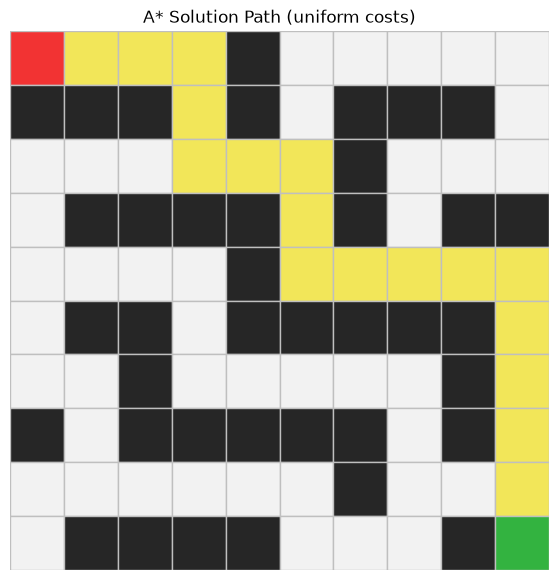

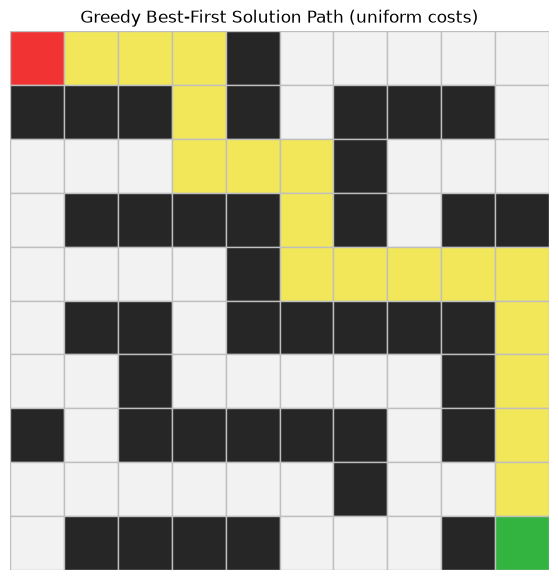

In [46]:
# Visualise two solution paths on the uniform map.
plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[1].path,
    title="A* Solution Path (uniform costs)",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=uniform_results[3].path,
    title="Greedy Best-First Solution Path (uniform costs)",
)

In [47]:
turbulence_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

turbulence_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 9, 9, 9, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

t_start = (2, 0)
t_goal = (2, 6)

turbulence_problem = WeightedGridProblem(
    turbulence_grid, t_start, t_goal, terrain_costs=turbulence_costs
)

turbulence_results = [
    ucs.search(turbulence_problem),
    astar.search(turbulence_problem),
    wastar2.search(turbulence_problem),
    greedy.search(turbulence_problem),
]

show_results(turbulence_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,10,10,26,12,35
1,A*,success,10,10,25,12,34
2,Weighted A* (W=2),success,10,10,13,13,26
3,Greedy,success,6,30,6,13,19


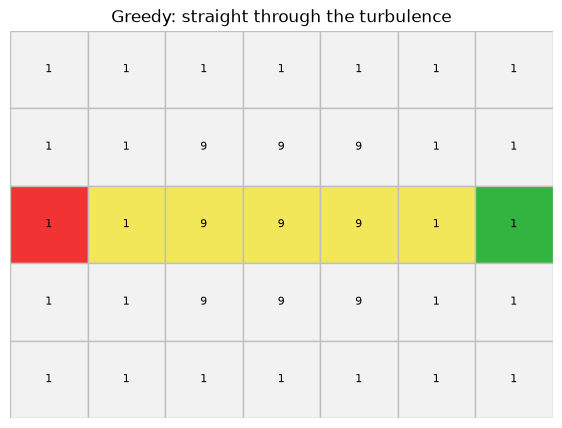

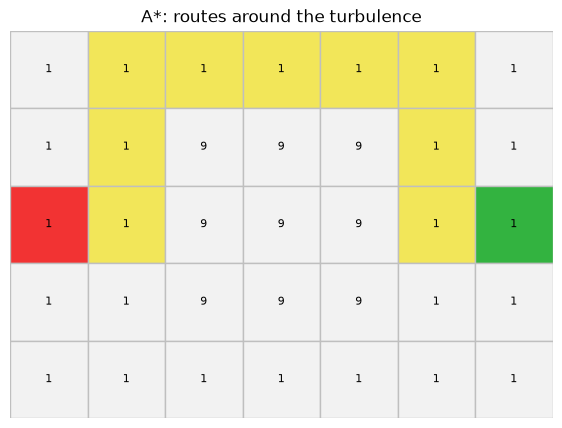

In [48]:
# Greedy vs A* on the turbulence map. The numbers printed in each cell
# are the terrain costs.
plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[3].path,
    terrain_costs=turbulence_costs,
    title="Greedy: straight through the turbulence",
)

plot_path(
    turbulence_grid,
    t_start,
    t_goal,
    path=turbulence_results[1].path,
    terrain_costs=turbulence_costs,
    title="A*: routes around the turbulence",
)

In [49]:
def inflated_heuristic(factor: float):
    # TODO 8:
    # Return a NEW heuristic function that overestimates by multiplying
    # Manhattan distance by `factor`.
    #
    # Steps:
    # 1. Define an inner function h(state, goal) that returns
    #    factor * manhattan_distance(state, goal).
    def h(state, goal):
        return factor * manhattan_distance(state, goal)

    # 2. Return the inner function (do not call it).
    return h
    #
    # Hint: this is a closure —
    # def h(state, goal):
    #     return ...
    # return h
    # raise NotImplementedError("Complete inflated_heuristic")


# Once TODO 8 is complete, run the comparison.
#
# The "mild turbulence" map below is designed to expose the inflated
# heuristic: the direct route through the cost-3 band costs 12, while the
# calm detour costs 10. An overconfident heuristic charges straight ahead.

mild_grid = [
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
]

mild_costs = [
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 3, 3, 3, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
]

mild_problem = WeightedGridProblem(mild_grid, (2, 0), (2, 6), terrain_costs=mild_costs)

astar_honest = AStarSearch(manhattan_distance)
astar_inflated = AStarSearch(inflated_heuristic(3.0))

experiment_results = [
    astar_honest.search(uniform_problem),
    astar_inflated.search(uniform_problem),
    astar_honest.search(mild_problem),
    astar_inflated.search(mild_problem),
]

# Relabel rows so the table is readable.
experiment_results[0].algorithm = "A* admissible (uniform map)"
experiment_results[1].algorithm = "A* inflated x3 (uniform map)"
experiment_results[2].algorithm = "A* admissible (mild turbulence)"
experiment_results[3].algorithm = "A* inflated x3 (mild turbulence)"

show_results(experiment_results)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,A* admissible (uniform map),success,18,18,18,5,23
1,A* inflated x3 (uniform map),success,18,18,18,5,23
2,A* admissible (mild turbulence),success,10,10,29,10,35
3,A* inflated x3 (mild turbulence),success,6,12,6,13,19


In [50]:
class IDAStarSearch(SearchAlgorithm):
    algorithm_name = "IDA*"

    def __init__(self, heuristic):
        self.heuristic = heuristic

    def search(self, problem: Problem, max_iterations: int = 200) -> SearchResult:
        # TODO 9 (BONUS, optional):
        # Implement IDA* following the pseudocode guide above.
        #
        # Requirements:
        initial_node = Node(problem.initial_state())
        limit = self.heuristic(initial_node.state, problem.is_goal)
        # 1. Start with limit = h(initial state).
        # 2. Each iteration performs a recursive f-limited depth-first search
        #    that uses path-cycle checking (reuse the idea from DLS in Part A:
        #    skip a child whose state already appears on the current path).
        # 3. Track total nodes_expanded across all iterations and the maximum
        #    recursion depth as max_frontier_size.
        # 4. Keep an iteration log of (limit, outcome) pairs in
        #    SearchResult.iterations.
        # 5. Return status "success", "failure" (next limit is infinity), or
        #    "cutoff" (max_iterations reached).
        raise NotImplementedError("Complete IDAStarSearch.search (bonus)")


# After completing the bonus, compare IDA* with A* here:
#  ida = IDAStarSearch(manhattan_distance)
# show_results([astar.search(uniform_problem), ida.search(uniform_problem)])

In [51]:
# TODO 10:
# Create your first custom map here (15 x 15)

custom_grid_1 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
]

custom_costs_1 = [
    [1, 1, 1, 2, 2, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1],
    [1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1],
    [1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 1, 0, 1],
    [0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1],
    [1, 1, 1, 1, 1, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1],
    [2, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1],
    [2, 2, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 2, 2, 1],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
    [1, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 2, 1, 0, 1],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1],
    [1, 1, 1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

custom_problem_1 = WeightedGridProblem(
    custom_grid_1, custom_start_1, custom_goal_1, terrain_costs=custom_costs_1
)

custom_results_1 = [
    ucs.search(custom_problem_1),
    astar.search(custom_problem_1),
    wastar2.search(custom_problem_1),
    greedy.search(custom_problem_1),
]

show_results(custom_results_1)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,28,29,107,8,113
1,A*,success,28,29,31,5,36
2,Weighted A* (W=2),success,28,29,28,5,33
3,Greedy,success,28,29,28,5,33


In [ ]:
# TODO 11:
# Create your second custom map here (20 x 20)

custom_grid_2 = [
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
    [1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0],
    [1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1],
    [1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1],
    [0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1],
    [0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0],
]

custom_costs_2 = [
    [1, 1, 1, 2, 2, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1, 2, 1, 0, 1, 1],
    [1, 0, 0, 0, 2, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1],
    [1, 1, 1, 0, 2, 2, 1, 0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1],
    [1, 1, 1, 1, 1, 0, 1, 2, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [2, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1],
    [2, 2, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 2, 2, 1, 1, 1, 0, 0, 1],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 1, 1],
    [1, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1],
    [1, 1, 1, 2, 2, 1, 1, 0, 1, 1, 1, 2, 1, 0, 1, 1, 1, 0, 1, 0],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1],
    [1, 1, 1, 1, 1, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1],
    [1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 2, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1],
    [1, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0],
    [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1],
    [1, 1, 1, 2, 2, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1],
]

custom_start_2 = (0, 0)
custom_goal_2 = (19, 19)

custom_problem_2 = WeightedGridProblem(
    custom_grid_2, custom_start_2, custom_goal_2, terrain_costs=custom_costs_2
)

custom_results_2 = [
    ucs.search(custom_problem_2),
    astar.search(custom_problem_2),
    wastar2.search(custom_problem_2),
    greedy.search(custom_problem_2),
]

show_results(custom_results_2)

,Algorithm,Status,Solution depth,Solution cost,Nodes expanded,Max frontier,Reached states
0,UCS,success,38,39,198,13,207
1,A*,success,38,39,42,7,48
2,Weighted A* (W=2),success,38,39,38,7,45
3,Greedy,success,38,39,38,7,45


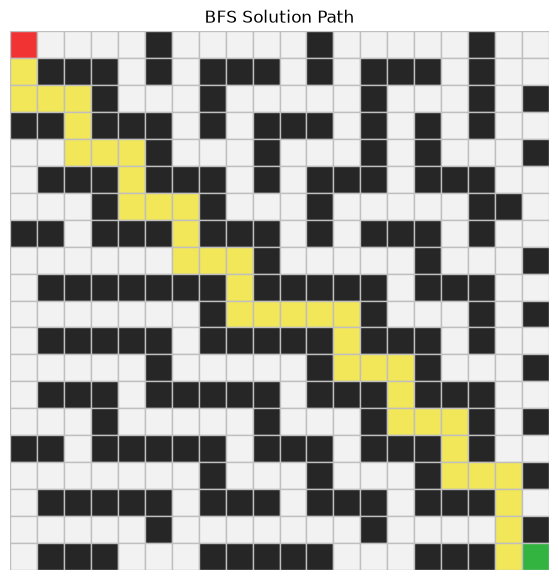

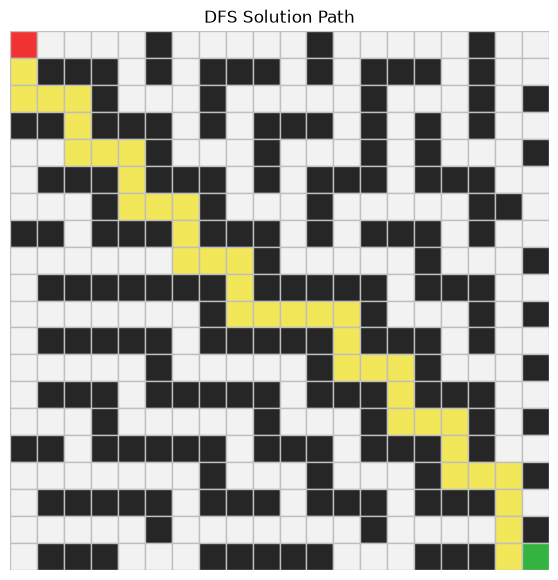

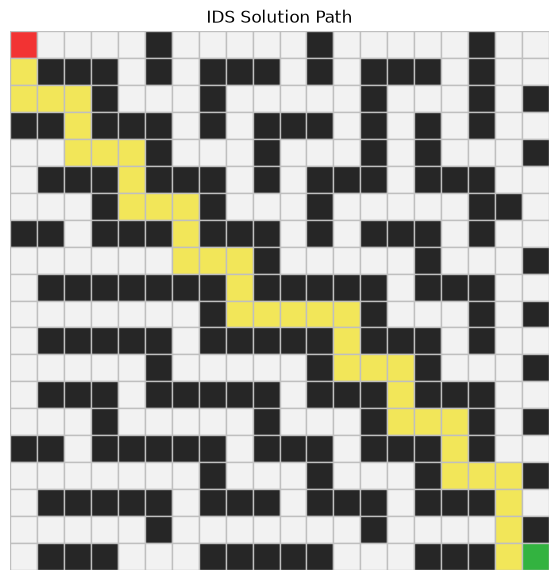

In [53]:
# Visualise solution paths.
# After your algorithms work, choose at least one algorithms and plot their paths.

bfs_result = custom_results_2[0]
dfs_result = custom_results_2[1]
ids_result = custom_results_2[3]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=dfs_result.path,
    title="DFS Solution Path",
)


plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=ids_result.path,
    title="IDS Solution Path",
)


**Heuristic Function**
**In your own words, what does h(n) estimate, and where does its "knowledge" come from in this lab**
h(n), the heuristic function estimates the cost it will take to reach the goal from the current position. It's knowledge comes from the straight line distance to the goal(Euclidean or Manhattan).

**Manhattan distance is the exact solution cost of a relaxed problem. Which restrictions of the original drone problem does that relaxation remove?**
It removes the obstacles and the different terrain costs. The drone can move freely without any blocks.

**Both Manhattan and Euclidean distance are admissible on our grid. Which one dominates the other, and what does domination predict about nodes expanded?**
Manhattance distance dominates Euclidean distance. This means A* with Manhattan will usually expand fewer or the same number of nodes compared to Euclidean

**Why does requiring all terrain costs o be >= 1 keep Manhattan distance admissible in the weighed maps? What could go wrong with a terrain cost of 0.5?**
Because the lowest cost per moce is 1, Manhattan distance will not overestimate the true cost. If a terrian cost wa 0.5, Manhattna could overstimate the cost, making the heuristic inadmissible and possibly breaking A* optimality.

**Greedy Best-First Search**
**Which quantity does Greedy ignore, and how did the turbulece map punish it for that?**
Greedy ignores the cost from the start. On the turbulence map, it got puuled toward high-cost area that looked closer to the goal, leading to very expensive paths.

**Greedy expanded fewer nodes than A on some maps. Why is that not enough to call it the better algorithm?**
Because it often finds much more expensive or longer paths. Expanding fewer nodes does not matter if the solution quality is poor.

**Describe a drone mission where Greedy's behaviour would actually be acceptable.**
A quick scouting mission where speed is more important than finding the absolute cheapest path, and getting close to the target fast is good enough.

**16.3 A* Search**

**Explain f(n) = g(n) + h(n) as a sentence about the drone's flight plan.**

f(n) is the estimated total cost of the flight plan: the known cost to reach the current position plus the estimated cost to go from there to the goal.

**Why must A apply the goal test when a node is popped rather than when it is generated? What could go wrong with an early goal test on the turbulence map? Why does reached need to be a dictionary (state → best node) in this lab, when a plain set was enough for BFS in Part A?**
Because a cheaper path to the goal might be found later. On the turbulence map, an early goal test could return a very expensive path.
The dictionary stores the best known cost to each state so the algorithm can update to better paths when found. A plain set cannot do this.

**Compare the nodes expanded by UCS and A on the sample map. What does this gap tell you about the value of the heuristic?**
A* expands far fewer nodes than UCS. This shows that the heuristic is effective at guiding the search and saving a lot of unnecessary work.

**16.4 Admissibility and Consistency**

**State the definitions of admissible and consistent. Which implies which?**
Admissible means the heuristic never overestimates the true cost to the goal.
Consistent means the heuristic satisfies the triangle inequality for every move.
Consistency implies admissibility (but not the other way around).

**What did your inadmissible-heuristic experiment show about the lecture's optimality claim?**
When the heuristic was inadmissible (overestimated), A* no longer found the optimal path. This confirms that admissibility is required for A* to guarantee the best solution.

**Is Manhattan distance consistent on our unit-cost grid? Check the triangle inequality h(n) ≤ c(n, a, n') + h(n') for a single move and explain.**
Yes, it is consistent. For any single move, the Manhattan distance decreases by at most 1, and the move cost is 1, so the inequality holds: h(n) ≤ 1 + h(n').

16.5 Weighted A* and Trade-offs

**How does the weight W interpolate between UCS, A, and Greedy?**
When W = 1, Weighted A* is the same as normal A*.
When W is very large, it behaves like Greedy (focuses only on h(n)).
Values between 1 and infinity gradually shift the balance between them.

**What suboptimality bound does Weighted A guarantee, and did your experiments stay well inside that bound?**
It guarantees the solution cost is at most W times the optimal cost. In the experiments, the solutions were usually much better than this worst-case bound.

**The drone has 90 seconds of battery margin and the flight computer is slow. Which algorithm and which W would you choose, and why?**
Weighted A* with a moderate W (such as 1.5 or 2). It finds reasonably good paths quickly without using too much computation time, while still staying safely within battery limits.

16.6 Memory and Real-World Drone Context

**Which data structures make A memory-hungry? How does IDA (bonus) avoid this, and what does it pay instead?**
The reached dictionary and the priority queue can grow very large.
IDA* avoids this by not storing all visited states, only the current path. It pays by repeating some search work at shallower depths.

**In a real drone application, what information would you fold into the terrain costs that this lab leaves out (weather forecasts, no-fly zones that change over time, battery state)?**
Current wind speed and direction, temporary no-fly zones, battery level (higher cost when battery is low), dynamic obstacles, and weather changes.

**Our heuristic assumes the goal never moves. What breaks if the drone is tracking a moving target, and which lecture concepts (e.g., learned heuristics, real-time search) become relevant?**
The heuristic becomes inaccurate as the target moves. Real-time search, replanning, and learned/adaptive heuristics would become important.

**Which single algorithm from Parts A and B combined would you ship on the drone, and under what conditions would you reconsider?**
Weighted A* with a small W (around 1.2–2).
Reconsider if the map is extremely large (then use IDA* for memory) or if real-time replanning is needed due to changing conditions.